In [14]:
""" Exam 3 """

import matplotlib.pyplot as plt
import numpy as np
from scipy import signal as sig
from math import pi, exp, cos, sin, log, sqrt, log10
from scipy.signal import lsim

In [15]:
# """ Butterworth HPF """

# wp = 6000
# Hp = .88
# ws = 5000
# Hs = .1

# wc = 5773 #guess this

# #Scale down and flip to LP

# wp = 1/(wp/wc)
# ws = 1/(ws/wc)

# Hp2 = (Hp)**2

# np = log10(1/Hp2 - 1)/(2*log10(wp))
# print('np =', np)

# Hs2 = (Hs)**2

# ns = log10(1/Hs2 - 1)/(2*log10(ws))
# print('ns =', ns)

In [16]:
""" Cheb_II HPF """

Hp = .88
Hs = .1
wp = 6000/5000
#ws = 5000/5000 = 1
wp0 = 1/wp

jj = complex(0,1)

eps = sqrt(Hs**2/(1-Hs**2))
aa = sqrt((1/eps**2)*(1/(1-Hp**2)))
bb = 1 / np.arccosh(1/wp0)
n = np.arccosh(aa)*bb
print('aa = ',aa,' bb= ',bb)
print('n = ', n)

print('eps = ',eps)
alpha = 1/eps + sqrt(1 + 1/eps**2)
print('alpha = ',alpha)
a = 0.5*(alpha**(1/n)-alpha**(-1/n))
b = 0.5*(alpha**(1/n) + alpha**(-1/n))
print('a = ',a,' b = ',b)

aa =  20.9482645399098  bb=  1.6067806046012827
n =  6.000735549773726
eps =  0.10050378152592122
alpha =  19.949874371066194
a =  0.5197530379547687  b =  1.1270063089722306


p1 = (0.5020428826527135+0.2916906967127092j)
q1 = (1.4891647448019298-0.8652159346152041j)
d1 = [1, 2.9783294896038597, 2.9662102506730577]
p2 = (0.36752089768012597+0.7969138035142858j)
q2 = (0.4772111055643344-1.034760525496768j)
d2 = [1, 0.9544222111286688, 1.2984597844002819]
p3 = (0.13452198497258744+1.0886045002269948j)
q3 = (0.11180760737081559-0.9047908753969502j)
d3 = [1, 0.22361521474163118, 0.831147469267566]
den = [ 1.          4.15636692  8.81782444 11.55624473 11.25651318  6.42849525
  3.2011684 ]
omega1 = 1.035276180410083
n1 = [0, 0, 0, 0, 1, 0, 1.0717967697244906]
omega2 = 1.414213562373095
n2 = [0, 0, 0, 0, 1, 0, 1.9999999999999996]
omega3 = 3.8637033051562737
n3 = [0, 0, 0, 0, 1, 0, 14.928203230275514]
num = [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  0. 18.  0. 48.  0.
 32.]
numk = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.101, 0, 1.818, 0, 4.848000000000001, 0, 3.232]
numh = [3.232, 0, 4.848000000000001, 0, 1.818, 0, 0.101, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

<>:79: SyntaxWarning: invalid escape sequence '\o'
<>:79: SyntaxWarning: invalid escape sequence '\o'
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_25816\3649932613.py:79: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$\omega$ (rad/s)')


Text(0, 0.5, '|H|')

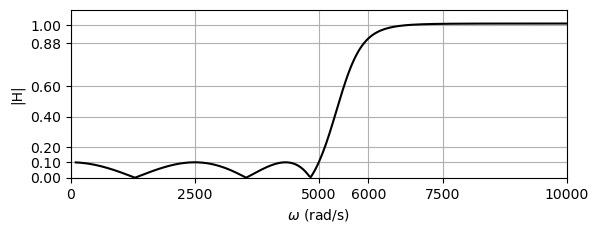

In [17]:
" Poles "
theta1 = np.deg2rad(15)
p1 = a*cos(theta1) + jj*b*sin(theta1)
q1 = 1/p1
d1 = [1,2*q1.real,(q1.real**2 + q1.imag**2)]
print('p1 =',p1)
print('q1 =',q1)
print('d1 =',d1)

theta2 = np.deg2rad(45)
p2 = a*cos(theta2) + jj*b*sin(theta2)
q2 = 1/p2
d2 = [1,2*q2.real,(q2.real**2 + q2.imag**2)]
print('p2 =',p2)
print('q2 =',q2)
print('d2 =',d2)

theta3 = np.deg2rad(75)
p3 = a*cos(theta3) + jj*b*sin(theta3)
q3 = 1/p3
d3 = [1,2*q3.real,(q3.real**2 + q3.imag**2)]
print('p3 =',p3)
print('q3 =',q3)
print('d3 =',d3)

d12 = np.convolve(d1,d2)
den = np.convolve(d12,d3)
print('den =',den)

" Zeros "
omega1 = 1/cos(1*np.pi/(12))
n1 = [0,0,0,0,1,0,omega1**2]
print('omega1 =',omega1)
print('n1 =',n1)

omega2 = 1/cos(3*np.pi/(12))
n2 = [0,0,0,0,1,0,omega2**2]
print('omega2 =',omega2)
print('n2 =',n2)

omega3 = 1/cos(5*np.pi/(12))
n3 = [0,0,0,0,1,0,omega3**2]
print('omega3 =',omega3)
print('n3 =',n3)

n12 = np.convolve(n1,n2)
num = np.convolve(n12,n3)
print('num =',num)

" Constant "
K = 0.101
num = [0,0,0,0,0,0,0,0,0,0,0,0,K,0,K*18,0,K*48,0,K*32]
print('numk =',num)

""" LPF to HPF """
numh = num[::-1]
denh = den[::-1]
print('numh =',numh)
print('denh =',denh)

""" Scale up """
a = 5000
nums = [numh[0],a*numh[1],(a**2)*numh[2],(a**3)*numh[3],(a**4)*numh[4],(a**5)*numh[5],(a**6)*numh[6]]
dens = [denh[0],a*denh[1],(a**2)*denh[2],(a**3)*denh[3],(a**4)*denh[4],(a**5)*denh[5],(a**6)*denh[6]]
print('nums =',nums)
print('dens =',dens)

""" Bode plot """
w = np.linspace(0.01, 10, 1000)
system = sig.lti(nums, dens)
w, Hmag, Hphase = sig.bode(system, n=1000)

plt.subplot(211)
plt.plot(w, 10**(0.05*Hmag), 'k')
plt.axis([0,10000, 0, 1.1])
plt.xticks([0,2500,5000,6000,7500,10000])
plt.yticks([0, .1, .2, .4, .6, .88, 1])
plt.grid(which='both')
plt.xlabel('$\omega$ (rad/s)')
plt.ylabel('|H|')

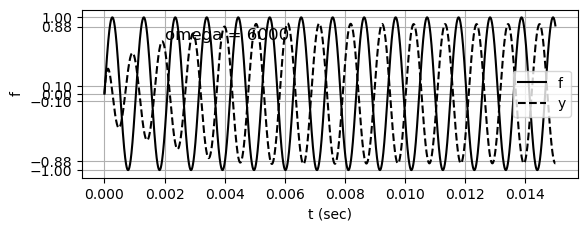

In [18]:
""" Time Domain Simulation """
omega = 5000
t = np.linspace(0, .015, 10000) #If omega is big, make second parameter really small
u = np.sin(omega*t)

tout, yout, xout = lsim((nums,dens), U=u, T=t)

plt.subplot(211)
plt.plot(t, u, 'k-', label='f')
plt.yticks([-1,-.88,-0.1,0,.1,.88,1])
plt.plot(tout, yout, 'k--', label='y')
plt.text(.002,.707,'omega = {}'.format(round(omega,1)),fontsize=12)
plt.grid()
plt.ylabel('f')
plt.xlabel('t (sec)')
plt.legend()
plt.show()